## Textbook

In [5]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
sys.path.append('./official_github/')
sys.path.append('./official_github/ch5.오차역전파법/')
from dataset.mnist import load_mnist
from common.util import smooth_curve

In [6]:
import sys
import os
import numpy as np
from collections import OrderedDict
sys.path.append(os.pardir)
from common.layers import *
from common.gradient import numerical_gradient

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size,
        weight_init_std=0.01):
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * \
            np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * \
            np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Affine1'] = \
            Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu1'] = Relu()
        self.layers['Affine2'] = \
            Affine(self.params['W2'], self.params['b2'])
        self.lastLayer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    # x : 입력 데이터, t : 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1:
            t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads

    def gradient(self, x, t):
        # 순전파
        self.loss(x, t)

        # 역전파
        dout = 1
        dout = self.lastLayer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        grads['W1'] = self.layers['Affine1'].dW
        grads['b1'] = self.layers['Affine1'].db
        grads['W2'] = self.layers['Affine2'].dW
        grads['b2'] = self.layers['Affine2'].db

        return grads


In [7]:
(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=False)
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

# 하이퍼 파라메터
iters_num = 10000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)

batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]
print(x_batch.shape, t_batch.shape)

(100, 784) (100,)


In [8]:


for i in range(iters_num):
    # print(i)
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 오차역전파법으로 기울기 계산
    grad = network.gradient(x_batch, t_batch)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭 당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

train acc, test acc | 0.0781, 0.0823
train acc, test acc | 0.9060333333333334, 0.9077
train acc, test acc | 0.9254833333333333, 0.926
train acc, test acc | 0.9388666666666666, 0.937
train acc, test acc | 0.9472333333333334, 0.9466
train acc, test acc | 0.94855, 0.9478
train acc, test acc | 0.95695, 0.9544
train acc, test acc | 0.9619, 0.9576
train acc, test acc | 0.9649, 0.9607
train acc, test acc | 0.9676166666666667, 0.963
train acc, test acc | 0.96955, 0.9646
train acc, test acc | 0.9717666666666667, 0.9647
train acc, test acc | 0.9727166666666667, 0.9653
train acc, test acc | 0.9743666666666667, 0.9669
train acc, test acc | 0.9759833333333333, 0.968
train acc, test acc | 0.9775, 0.9693
train acc, test acc | 0.9773, 0.9694


## My own

In [9]:
from my_models import batch_mask_loader

In [10]:
(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=False)

# 하이퍼 파라메터
iters_num = 10000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1

train_loss_list_2 = []
train_acc_list_2 = []
test_acc_list_2 = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)

batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]
print(x_batch.shape, t_batch.shape)

(100, 784) (100,)


In [11]:
network = TwoLayerNet(784, 50, 10)

epoch = 16
iter_idx = 0
for epoch_idx in range(1, epoch+1):
    print(f"===== {epoch_idx} epoch started =====")
    batch_masks = batch_mask_loader(x_train, batch_size=batch_size)

    for batch_mask in batch_masks:
        
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
        print(x_batch.shape, t_batch.shape)
        
        grad = network.gradient(x_batch, t_batch)
        
        for key in network.params.keys():
            network.params[key] -= learning_rate * grad[key]
    
        loss = network.loss(x_batch, t_batch)
        print(f'{iter_idx} loss: {loss}')
        train_loss_list_2.append(loss)
        
        if iter_idx % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            train_acc_list_2.append(train_acc)
            test_acc_list_2.append(test_acc)
            print(f'===== train acc: {train_acc}, test acc: {test_acc} =====')

        iter_idx += 1

print(f'final train acc:{network.accuracy(x_train, t_train)}')
print(f'final test acc:{network.accuracy(x_test, t_test)}') 

===== 1 epoch started =====
(100, 784) (100,)
0 loss: 2.301036450927431
===== train acc: 0.15485, test acc: 0.1535 =====
(100, 784) (100,)
1 loss: 2.2996890910586445
(100, 784) (100,)
2 loss: 2.2996471662245446
(100, 784) (100,)
3 loss: 2.299760185938599
(100, 784) (100,)
4 loss: 2.299514476129224
(100, 784) (100,)
5 loss: 2.2988416603932893
(100, 784) (100,)
6 loss: 2.2985136072232213
(100, 784) (100,)
7 loss: 2.297976054712492
(100, 784) (100,)
8 loss: 2.2939516389921852
(100, 784) (100,)
9 loss: 2.2954696845267026
(100, 784) (100,)
10 loss: 2.2991878517467472
(100, 784) (100,)
11 loss: 2.299175932821042
(100, 784) (100,)
12 loss: 2.2959706281235333
(100, 784) (100,)
13 loss: 2.2946512640845373
(100, 784) (100,)
14 loss: 2.292694219900477
(100, 784) (100,)
15 loss: 2.2904561959997918
(100, 784) (100,)
16 loss: 2.2952997585971975
(100, 784) (100,)
17 loss: 2.2909293950291634
(100, 784) (100,)
18 loss: 2.290330080850073
(100, 784) (100,)
19 loss: 2.288684688442746
(100, 784) (100,)
20 

## what if exhaustive NO SHUFFLE?

In [12]:
from my_models import batch_mask_loader

In [13]:
(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=False)

# 하이퍼 파라메터
iters_num = 10000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1

train_loss_list_3 = []
train_acc_list_3 = []
test_acc_list_3 = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)

batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]
print(x_batch.shape, t_batch.shape)

(100, 784) (100,)


In [14]:
network = TwoLayerNet(784, 50, 10)

epoch = 16
iter_idx = 0
for epoch_idx in range(1, epoch+1):
    print(f"===== {epoch_idx} epoch started =====")
    batch_masks = batch_mask_loader(x_train, batch_size=batch_size, shuffle=False)

    for batch_mask in batch_masks:
        
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
        print(x_batch.shape, t_batch.shape)
        
        grad = network.gradient(x_batch, t_batch)
        
        for key in network.params.keys():
            network.params[key] -= learning_rate * grad[key]
    
        loss = network.loss(x_batch, t_batch)
        print(f'{iter_idx} loss: {loss}')
        train_loss_list_3.append(loss)
        
        if iter_idx % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            train_acc_list_3.append(train_acc)
            test_acc_list_3.append(test_acc)
            print(f'===== train acc: {train_acc}, test acc: {test_acc} =====')

        iter_idx += 1

print(f'final train acc:{network.accuracy(x_train, t_train)}')
print(f'final test acc:{network.accuracy(x_test, t_test)}') 

===== 1 epoch started =====
(100, 784) (100,)
0 loss: 2.300594772515793
===== train acc: 0.10838333333333333, test acc: 0.1083 =====
(100, 784) (100,)
1 loss: 2.300642021514367
(100, 784) (100,)
2 loss: 2.3001930913489095
(100, 784) (100,)
3 loss: 2.2982948174527245
(100, 784) (100,)
4 loss: 2.2983310232506393
(100, 784) (100,)
5 loss: 2.2990756630556346
(100, 784) (100,)
6 loss: 2.296880649745184
(100, 784) (100,)
7 loss: 2.2983367130489025
(100, 784) (100,)
8 loss: 2.296855704850301
(100, 784) (100,)
9 loss: 2.294090375485064
(100, 784) (100,)
10 loss: 2.293454419983515
(100, 784) (100,)
11 loss: 2.293858829313204
(100, 784) (100,)
12 loss: 2.295300563199814
(100, 784) (100,)
13 loss: 2.2897170832254377
(100, 784) (100,)
14 loss: 2.293475659272397
(100, 784) (100,)
15 loss: 2.2939221865274586
(100, 784) (100,)
16 loss: 2.287612329038984
(100, 784) (100,)
17 loss: 2.2879552697094074
(100, 784) (100,)
18 loss: 2.285675664075871
(100, 784) (100,)
19 loss: 2.2845890353707174
(100, 784) (

## 결과 시각화


In [ ]:
from common.util import smooth_curve

In [15]:
# train_acc_list = train_acc_list[:90]
# test_acc_list = test_acc_list[:90]

In [16]:
print(list(map(len, [train_acc_list, test_acc_list, train_acc_list_2])))

[17, 17, 16]


Text(0.5, 0.98, 'Batch Sampling: random without replace vs shuffle & exhaustive')

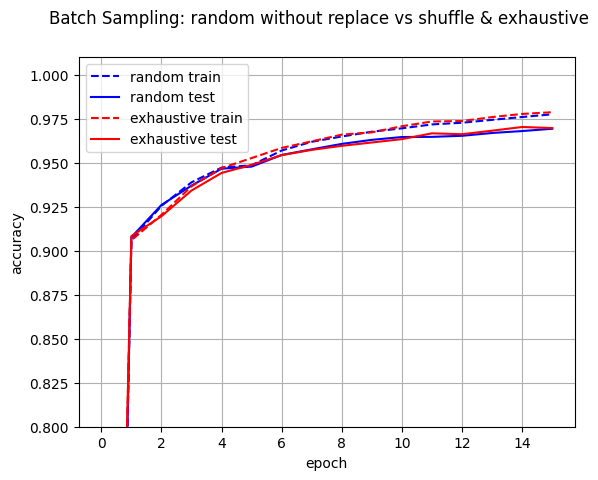

In [27]:
plt.plot(train_acc_list[:16], color='b', linestyle='dashed', label='random train')
plt.plot(test_acc_list[:16], color='b', label='random test')
plt.plot(train_acc_list_2, color='r', linestyle='dashed', label='exhaustive train')
plt.plot(test_acc_list_2, color='r', label='exhaustive test')
# plt.plot(train_acc_list_3, color='g', linestyle='dashed', label='exhaustive No SHUFFLE train')
# plt.plot(test_acc_list_3, color='g', label='exhaustive No SHUFFLE test')
# plt.plot(train_acc_list_3, color='g', linestyle='dashed')
# plt.plot(test_acc_list_3, color='g')
plt.ylim(0.8, 1.01)
plt.legend()
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.grid()
plt.suptitle('Batch Sampling: random without replace vs shuffle & exhaustive')

Text(0.5, 0.98, 'Batch Sampling: random without replace vs shuffle & exhaustive')

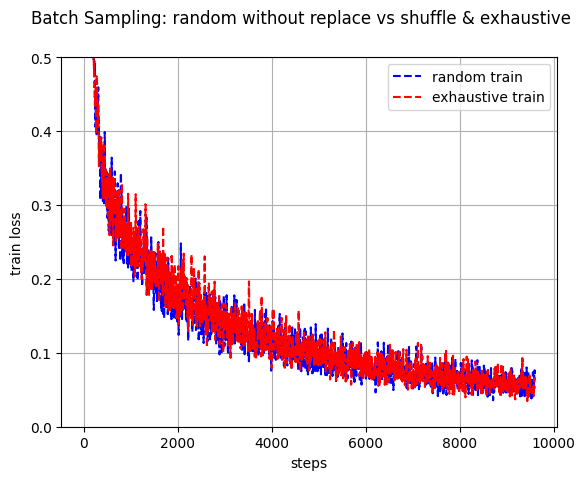

In [42]:
x = range(ml:=len(train_loss_list_2))
plt.plot(x, smooth_curve(train_loss_list[:ml]), color='b', linestyle='dashed', label='random train')
plt.plot(x, smooth_curve(train_loss_list_2), color='r', linestyle='dashed', label='exhaustive train')
# plt.plot(train_acc_list_3, color='g', linestyle='dashed', label='exhaustive No SHUFFLE train')
# plt.plot(test_acc_list_3, color='g', label='exhaustive No SHUFFLE test')
# plt.plot(train_acc_list_3, color='g', linestyle='dashed')
# plt.plot(test_acc_list_3, color='g')
plt.ylim(0., 0.5)
plt.legend()
plt.ylabel('train loss')
plt.xlabel('steps')
plt.grid()
plt.suptitle('Batch Sampling: random without replace vs shuffle & exhaustive')